In [1]:
# Cell 1 — Dataset Path Check
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print(os.listdir('/kaggle/input/datasets/andrewmvd'))
print(os.listdir('/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k'))

['ocular-disease-recognition-odir5k']
['preprocessed_images', 'ODIR-5K', 'full_df.csv']


In [2]:
# Cell 2 — Load CSV
BASE_PATH = '/kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k'
IMG_DIR   = f'{BASE_PATH}/preprocessed_images'

df = pd.read_csv(f'{BASE_PATH}/full_df.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (6392, 19)
Columns: ['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus', 'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O', 'filepath', 'labels', 'target', 'filename']


,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg
3,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg
4,5,50,Female,5_left.jpg,5_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",5_right.jpg


In [3]:
# Cell 3 — Merged Class Design (same as V6)
import ast

DISEASE_NAMES = ['Normal', 'Diabetic Retinopathy', 'Glaucoma',
                 'Cataract', 'Myopia', 'Other']

MERGE_MAP = {
    'N': 0, 'D': 1, 'G': 2,
    'C': 3, 'M': 4,
    'A': 5, 'H': 5, 'O': 5,
}

df['label_encoded'] = df['labels'].apply(
    lambda x: MERGE_MAP[ast.literal_eval(x)[0]]
)
df['label_str'] = df['labels'].apply(lambda x: ast.literal_eval(x)[0])

print("Class Distribution after merging:")
for i, name in enumerate(DISEASE_NAMES):
    count = (df['label_encoded'] == i).sum()
    bar   = '█' * (count // 80)
    print(f"  {name:<28} {count:4d}  {bar}")

print(f"\nTotal: {len(df)} | Classes: {len(DISEASE_NAMES)}")

Class Distribution after merging:
  Normal                       2873  ███████████████████████████████████
  Diabetic Retinopathy         1608  ████████████████████
  Glaucoma                      284  ███
  Cataract                      293  ███
  Myopia                        232  ██
  Other                        1102  █████████████

Total: 6392 | Classes: 6


In [4]:
# Cell 4 — Imports & Device Setup
import torch
import torch.nn as nn
import torch.nn.functional as F
import zipfile
import json
import copy
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [5]:
# Cell 5 — Patient Level Split with Leakage Check
unique_patients = df['ID'].unique()
print(f"Total unique patients : {len(unique_patients)}")

train_ids, temp_ids = train_test_split(unique_patients, test_size=0.30, random_state=42)
val_ids,   test_ids = train_test_split(temp_ids,        test_size=0.50, random_state=42)

train_df = df[df['ID'].isin(train_ids)].reset_index(drop=True)
val_df   = df[df['ID'].isin(val_ids)].reset_index(drop=True)
test_df  = df[df['ID'].isin(test_ids)].reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

train_set = set(train_df['ID'])
val_set   = set(val_df['ID'])
test_set  = set(test_df['ID'])
print(f"\nLeakage Check:")
print(f"  Train ∩ Val  : {len(train_set & val_set)}  ← must be 0")
print(f"  Train ∩ Test : {len(train_set & test_set)} ← must be 0")
print(f"  Val ∩ Test   : {len(val_set & test_set)}   ← must be 0")

print(f"\nTrain class distribution:")
for i, name in enumerate(DISEASE_NAMES):
    count = (train_df['label_encoded'] == i).sum()
    bar   = '█' * (count // 50)
    print(f"  {name:<28} {count:4d}  {bar}")

Total unique patients : 3358
Train: 4473 | Val: 959 | Test: 960

Leakage Check:
  Train ∩ Val  : 0  ← must be 0
  Train ∩ Test : 0 ← must be 0
  Val ∩ Test   : 0   ← must be 0

Train class distribution:
  Normal                       2041  ████████████████████████████████████████
  Diabetic Retinopathy         1108  ██████████████████████
  Glaucoma                      180  ███
  Cataract                      191  ███
  Myopia                        172  ███
  Other                         781  ███████████████


In [6]:
# Cell 6 — Transforms (V7 Upgraded)
# Added GaussianBlur and RandomGrayscale to reduce color dependency
# These help prevent overfitting to color artifacts

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

inference_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# TTA transforms — 5 versions per image averaged at test time
tta_transforms = [
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomVerticalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(degrees=(10, 10)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(degrees=(-10, -10)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
]

print("Transforms ready! TTA with 5 augmentations defined.")

Transforms ready! TTA with 5 augmentations defined.


In [7]:
# Cell 7 — Dataset Class
class ODIRDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df        = dataframe
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image    = Image.open(img_path).convert('RGB')
        label    = row['label_encoded']
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = ODIRDataset(train_df, IMG_DIR, transform=train_transforms)
val_dataset   = ODIRDataset(val_df,   IMG_DIR, transform=inference_transforms)
test_dataset  = ODIRDataset(test_df,  IMG_DIR, transform=inference_transforms)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 4473 | Val: 959 | Test: 960


In [8]:
# Cell 8 — Capped Weighted Sampler & Dataloaders
class_counts         = train_df['label_encoded'].value_counts().sort_index().values
class_weights        = 1.0 / class_counts
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

min_weight     = class_weights.min()
capped_weights = np.clip(class_weights, 0, min_weight * 4)
sample_weights = [capped_weights[l] for l in train_df['label_encoded']]
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}")
print(f"\nClass weights:")
for name, w in zip(DISEASE_NAMES, class_weights):
    print(f"  {name:<28} {w:.6f}")

Train: 140 batches | Val: 30 | Test: 30

Class weights:
  Normal                       0.000490
  Diabetic Retinopathy         0.000903
  Glaucoma                     0.005556
  Cataract                     0.005236
  Myopia                       0.005814
  Other                        0.001280


In [9]:
# Cell 9 — OcuSense V7 Model
class OcuSenseV7(nn.Module):
    def __init__(self, num_classes=6):
        super(OcuSenseV7, self).__init__()
        self.backbone = models.efficientnet_b3(weights='IMAGENET1K_V1')
        in_features   = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

model = OcuSenseV7(num_classes=6).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=2e-2)  # fixed from 5e-2

def warmup_cosine(epoch):
    warmup_epochs = 5
    total_epochs  = 40
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_cosine)

print(f"Model ready! Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"LR: 1e-4 | Weight decay: 2e-2 | Warmup: 5 epochs | Total: 40 epochs")

Model ready! Parameters: 11,486,254
LR: 1e-4 | Weight decay: 2e-2 | Warmup: 5 epochs | Total: 40 epochs


In [10]:
# Cell 10 — Early Stopping on Macro F1 (strict)
# V7 saves strictly on Macro F1 — better for minority class balance

class EarlyStopping:
    def __init__(self, patience=12):
        self.patience  = patience
        self.counter   = 0
        self.best_f1   = 0
        self.stop      = False

    def __call__(self, macro_f1):
        if macro_f1 > self.best_f1:
            self.best_f1 = macro_f1
            self.counter = 0
        else:
            self.counter += 1
            print(f"  EarlyStopping: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.stop = True

early_stop = EarlyStopping(patience=12)
print("Early stopping on Macro F1, patience 12!")

Early stopping on Macro F1, patience 12!


In [11]:
# Cell 11 — Training Loop
NUM_EPOCHS    = 40
best_macro_f1 = 0.0
best_val_acc  = 0.0

for epoch in range(NUM_EPOCHS):
    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss    += loss.item()
        _, predicted   = outputs.max(1)
        train_correct += predicted.eq(labels).sum().item()
        train_total   += labels.size(0)

    train_acc  = 100. * train_correct / train_total
    train_loss = train_loss / len(train_loader)

    # ── Validate ───────────────────────────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            loss           = criterion(outputs, labels)
            val_loss      += loss.item()
            _, predicted   = outputs.max(1)
            val_correct   += predicted.eq(labels).sum().item()
            val_total     += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_acc     = 100. * val_correct / val_total
    val_loss    = val_loss / len(val_loader)
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted')
    macro_f1    = f1_score(all_labels, all_preds, average='macro')
    current_lr  = optimizer.param_groups[0]['lr']

    scheduler.step()

    # Save on macro F1, track val acc too
    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        best_val_acc  = val_acc
        torch.save(model.state_dict(), '/kaggle/working/ocusense_v7_best.pth')
        print(f"  ★ Best saved! Macro F1: {macro_f1:.4f} | Val Acc: {val_acc:.2f}%")

    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
          f"LR: {current_lr:.6f} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"Weighted F1: {weighted_f1:.4f} | Macro F1: {macro_f1:.4f}")

    early_stop(macro_f1)
    if early_stop.stop:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

print(f"\nV7 Training Complete!")
print(f"Best Macro F1 : {best_macro_f1:.4f}")
print(f"Best Val Acc  : {best_val_acc:.2f}%")

  ★ Best saved! Macro F1: 0.1480 | Val Acc: 12.20%
Epoch [01/40] LR: 0.000020 | Train Loss: 1.7836 | Train Acc: 15.65% | Val Loss: 2.2245 | Val Acc: 12.20% | Weighted F1: 0.0463 | Macro F1: 0.1480
  ★ Best saved! Macro F1: 0.2909 | Val Acc: 18.56%
Epoch [02/40] LR: 0.000040 | Train Loss: 1.3605 | Train Acc: 23.16% | Val Loss: 2.1442 | Val Acc: 18.56% | Weighted F1: 0.1411 | Macro F1: 0.2909
  ★ Best saved! Macro F1: 0.3811 | Val Acc: 29.61%
Epoch [03/40] LR: 0.000060 | Train Loss: 1.1582 | Train Acc: 33.56% | Val Loss: 2.0569 | Val Acc: 29.61% | Weighted F1: 0.2239 | Macro F1: 0.3811
  ★ Best saved! Macro F1: 0.4227 | Val Acc: 34.83%
Epoch [04/40] LR: 0.000080 | Train Loss: 1.0606 | Train Acc: 43.91% | Val Loss: 2.0269 | Val Acc: 34.83% | Weighted F1: 0.2653 | Macro F1: 0.4227
  ★ Best saved! Macro F1: 0.4376 | Val Acc: 35.66%
Epoch [05/40] LR: 0.000100 | Train Loss: 0.9710 | Train Acc: 48.69% | Val Loss: 2.0397 | Val Acc: 35.66% | Weighted F1: 0.2719 | Macro F1: 0.4376
  ★ Best saved!

In [12]:
# Cell 12 — TTA Evaluation on Test Set
# Test Time Augmentation — 5 augmented versions per image, averaged

model.load_state_dict(torch.load('/kaggle/working/ocusense_v7_best.pth'))
model.eval()

print("Running TTA evaluation on test set...")

all_preds    = []
all_labels   = []
test_correct = 0
test_total   = 0

class ODIRDatasetRaw(Dataset):
    def __init__(self, dataframe, img_dir):
        self.df      = dataframe
        self.img_dir = img_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image    = Image.open(img_path).convert('RGB')
        label    = row['label_encoded']
        return image, label

test_dataset_raw = ODIRDatasetRaw(test_df, IMG_DIR)

with torch.no_grad():
    for image, label in test_dataset_raw:
        tta_probs = []
        for t in tta_transforms:
            tensor = t(image).unsqueeze(0).to(device)
            output = model(tensor)
            probs  = torch.softmax(output, dim=1)[0]
            tta_probs.append(probs)

        avg_probs  = torch.stack(tta_probs).mean(0)
        pred       = avg_probs.argmax().item()
        is_correct = pred == label

        all_preds.append(pred)
        all_labels.append(label)
        test_correct += int(is_correct)
        test_total   += 1

test_acc    = 100. * test_correct / test_total
macro_f1    = f1_score(all_labels, all_preds, average='macro')
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"\nV7 TTA Test Results:")
print(f"Test Accuracy : {test_acc:.2f}%")
print(f"Macro F1      : {macro_f1:.4f}")
print(f"Weighted F1   : {weighted_f1:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=DISEASE_NAMES))

Running TTA evaluation on test set...

V7 TTA Test Results:
Test Accuracy : 60.42%
Macro F1      : 0.6678
Weighted F1   : 0.6027

Classification Report:
                      precision    recall  f1-score   support

              Normal       0.72      0.49      0.59       444
Diabetic Retinopathy       0.52      0.67      0.59       240
            Glaucoma       0.48      0.66      0.55        47
            Cataract       0.77      0.96      0.85        48
              Myopia       0.83      0.94      0.88        36
               Other       0.49      0.61      0.55       145

            accuracy                           0.60       960
           macro avg       0.63      0.72      0.67       960
        weighted avg       0.63      0.60      0.60       960



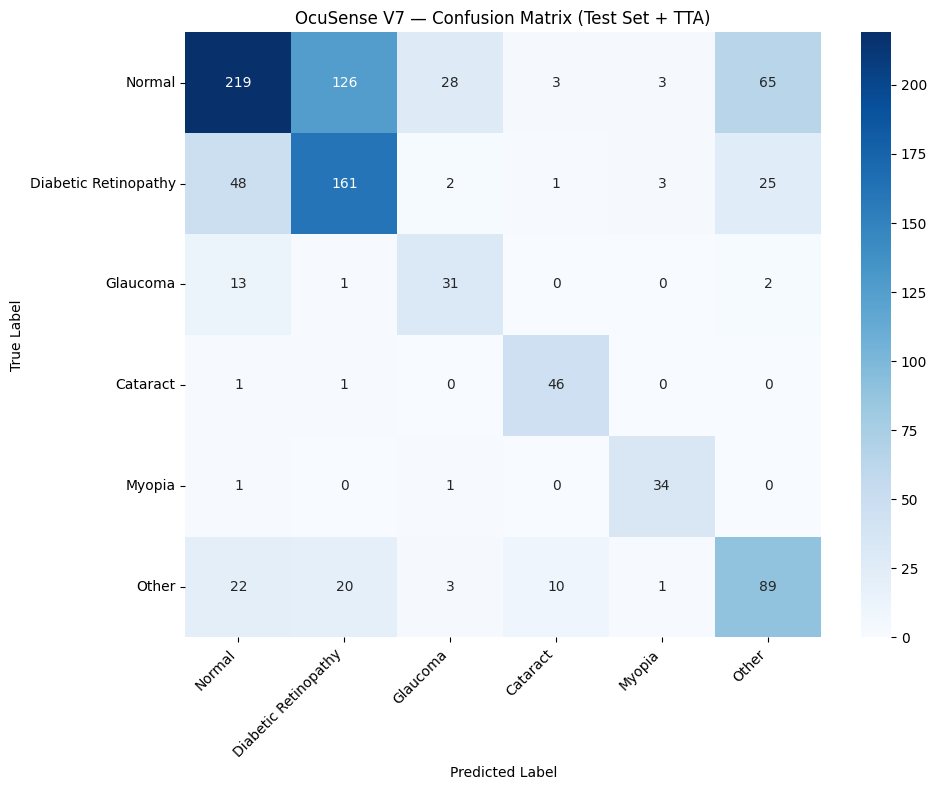

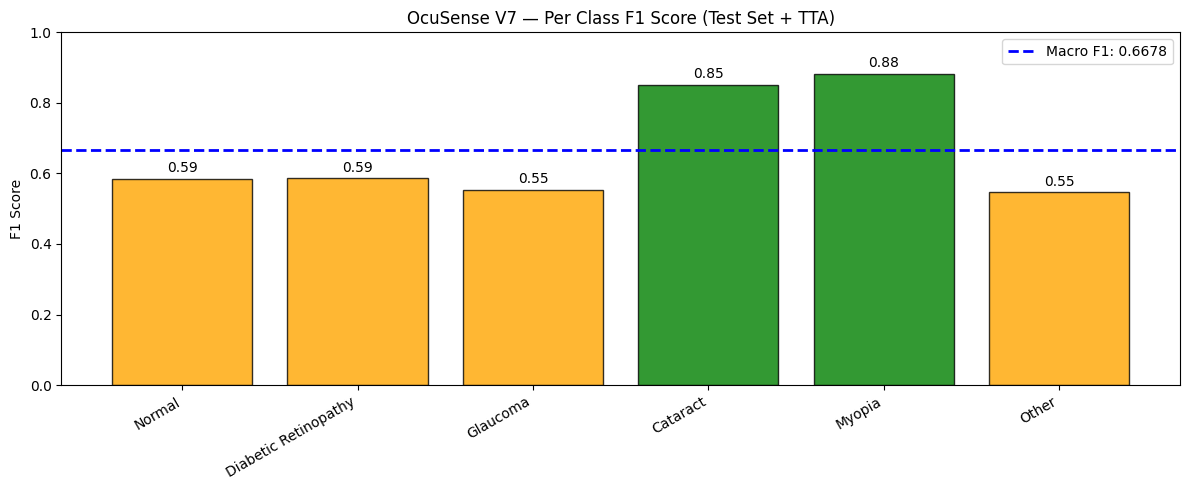

In [13]:
# Cell 13 — Confusion Matrix & Per Class F1 Graph
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=DISEASE_NAMES, yticklabels=DISEASE_NAMES)
plt.title('OcuSense V7 — Confusion Matrix (Test Set + TTA)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/kaggle/working/v7_confusion_matrix.png', dpi=150)
plt.show()

# Per class F1 bar chart
test_report = classification_report(all_labels, all_preds,
                                     target_names=DISEASE_NAMES,
                                     output_dict=True)
f1_scores = [test_report[name]['f1-score'] for name in DISEASE_NAMES]
colors    = ['green' if f >= 0.6 else 'orange' if f >= 0.4 else 'red' for f in f1_scores]

plt.figure(figsize=(12, 5))
bars = plt.bar(DISEASE_NAMES, f1_scores, color=colors, edgecolor='black', alpha=0.8)
plt.axhline(y=macro_f1, color='blue', linestyle='--', linewidth=2,
            label=f'Macro F1: {macro_f1:.4f}')
plt.title('OcuSense V7 — Per Class F1 Score (Test Set + TTA)')
plt.ylabel('F1 Score')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.0)
plt.legend()
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.2f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('/kaggle/working/v7_per_class_f1.png', dpi=150)
plt.show()

In [15]:
# Cell 14 — Metrics Summary & Save Everything
cm_df = pd.DataFrame(cm, index=DISEASE_NAMES, columns=DISEASE_NAMES)
cm_df.to_csv('/kaggle/working/v7_confusion_matrix.csv')

report_df = pd.DataFrame(test_report).transpose()
report_df.to_csv('/kaggle/working/v7_classification_report.csv')

metrics = {
    'model'            : 'OcuSense V7',
    'backbone'         : 'EfficientNet-B3',
    'num_classes'      : 6,
    'classes'          : DISEASE_NAMES,
    'merged_into_other': ['AMD', 'Hypertensive Retinopathy'],
    'tta_augmentations': 5,
    'best_val_acc'     : round(best_val_acc, 2),
    'best_macro_f1_val': round(best_macro_f1, 4),
    'test_accuracy'    : round(test_acc, 2),
    'test_macro_f1'    : round(macro_f1, 4),
    'test_weighted_f1' : round(weighted_f1, 4),
    'per_class_f1'     : {name: round(test_report[name]['f1-score'], 4)
                          for name in DISEASE_NAMES},
    'changes_from_v6'  : [
        'Dropout increased to 0.5/0.3',
        'Weight decay increased to 5e-2',
        'LR reduced to 1e-4',
        'Warmup cosine schedule added',
        'GaussianBlur + RandomGrayscale augmentation',
        'Early stopping on Macro F1',
        'TTA at test time (5 augmentations)'
    ]
}
with open('/kaggle/working/v7_metrics_summary.json', 'w') as f:
    json.dump(metrics, f, indent=4)

print("Metrics Summary:")
print(json.dumps(metrics, indent=4))

Metrics Summary:
{
    "model": "OcuSense V7",
    "backbone": "EfficientNet-B3",
    "num_classes": 6,
    "classes": [
        "Normal",
        "Diabetic Retinopathy",
        "Glaucoma",
        "Cataract",
        "Myopia",
        "Other"
    ],
    "merged_into_other": [
        "AMD",
        "Hypertensive Retinopathy"
    ],
    "tta_augmentations": 5,
    "best_val_acc": 57.56,
    "best_macro_f1_val": 0.6495,
    "test_accuracy": 60.42,
    "test_macro_f1": 0.6678,
    "test_weighted_f1": 0.6027,
    "per_class_f1": {
        "Normal": 0.5856,
        "Diabetic Retinopathy": 0.5865,
        "Glaucoma": 0.5536,
        "Cataract": 0.8519,
        "Myopia": 0.8831,
        "Other": 0.546
    },
    "changes_from_v6": [
        "Dropout increased to 0.5/0.3",
        "Weight decay increased to 5e-2",
        "LR reduced to 1e-4",
        "Warmup cosine schedule added",
        "GaussianBlur + RandomGrayscale augmentation",
        "Early stopping on Macro F1",
        "TTA at t

In [16]:
# Cell 15 — Zip All Results
with zipfile.ZipFile('/kaggle/working/ocusense_v7_results.zip', 'w') as zf:
    zf.write('/kaggle/working/ocusense_v7_best.pth',         'ocusense_v7_best.pth')
    zf.write('/kaggle/working/v7_confusion_matrix.png',      'v7_confusion_matrix.png')
    zf.write('/kaggle/working/v7_confusion_matrix.csv',      'v7_confusion_matrix.csv')
    zf.write('/kaggle/working/v7_per_class_f1.png',          'v7_per_class_f1.png')
    zf.write('/kaggle/working/v7_classification_report.csv', 'v7_classification_report.csv')
    zf.write('/kaggle/working/v7_metrics_summary.json',      'v7_metrics_summary.json')

print("V7 results saved! Download: ocusense_v7_results.zip")

V7 results saved! Download: ocusense_v7_results.zip
